In [19]:
# ============================================================
# STEP 1: INSTALL REQUIRED LIBRARIES
# ============================================================

# Run this in terminal or command prompt
# pip install pandas matplotlib seaborn folium

# ============================================================
# STEP 2: IMPORT LIBRARIES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap

# ============================================================
# STEP 3: LOAD DATASET
# ============================================================

df = pd.read_csv("/content/traffic_accident_data.csv")

# Display first 5 rows
print(df.head())

# ============================================================
# STEP 4: DATASET INFORMATION
# ============================================================

print("\nDataset Info:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

print("\nStatistical Summary:\n")
print(df.describe())

  Accident_ID        Date  Hour Time_of_Day      Road_Condition  \
0      ACC001  2025-03-16    14   Afternoon                 Icy   
1      ACC002  2025-02-11    23       Night                 Wet   
2      ACC003  2025-04-02     4       Night  Under Construction   
3      ACC004  2025-07-12     5       Night                 Wet   
4      ACC005  2025-05-02    14   Afternoon                 Wet   

  Weather_Condition Severity  Vehicles_Involved Vehicle_Type  \
0             Rainy    Minor                  3          Bus   
1             Clear    Major                  2         Bike   
2             Rainy    Minor                  2          Bus   
3             Clear    Minor                  5        Truck   
4             Clear    Fatal                  5        Truck   

            Location   Latitude  Longitude  Casualties  
0       Airport Road  17.440137  78.442199           0  
1       Airport Road  17.434594  78.456778           1  
2     Highway Exit 5  17.421122  78.50010


Road Condition Counts:

Road_Condition
Wet                   183
Dry                    55
Icy                    46
Under Construction     38
Snowy                  28
Name: count, dtype: int64


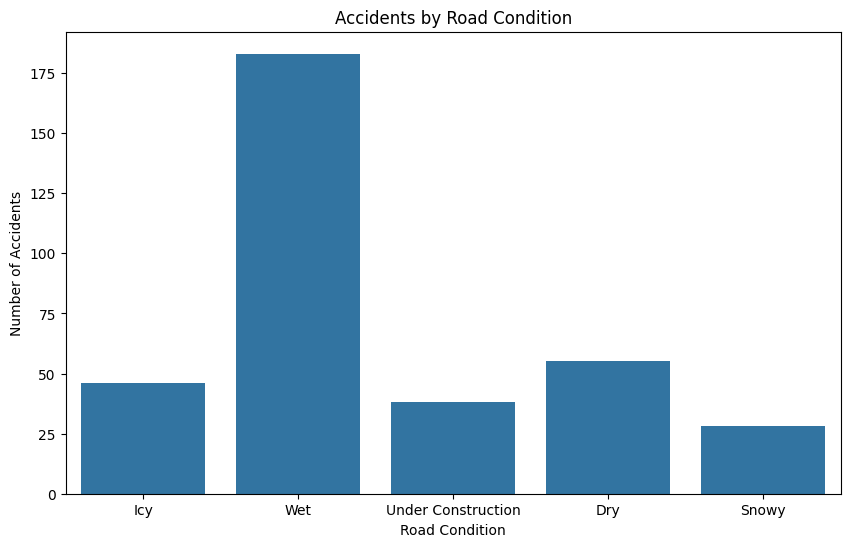

In [20]:
# ============================================================
# STEP 5: ROAD CONDITION ANALYSIS
# ============================================================

print("\nRoad Condition Counts:\n")
print(df['Road_Condition'].value_counts())

plt.figure(figsize=(10,6))

sns.countplot(x='Road_Condition', data=df)

plt.title('Accidents by Road Condition')
plt.xlabel('Road Condition')
plt.ylabel('Number of Accidents')

plt.show()


Weather Condition Counts:

Weather_Condition
Rainy     170
Clear      57
Foggy      45
Cloudy     41
Stormy     37
Name: count, dtype: int64


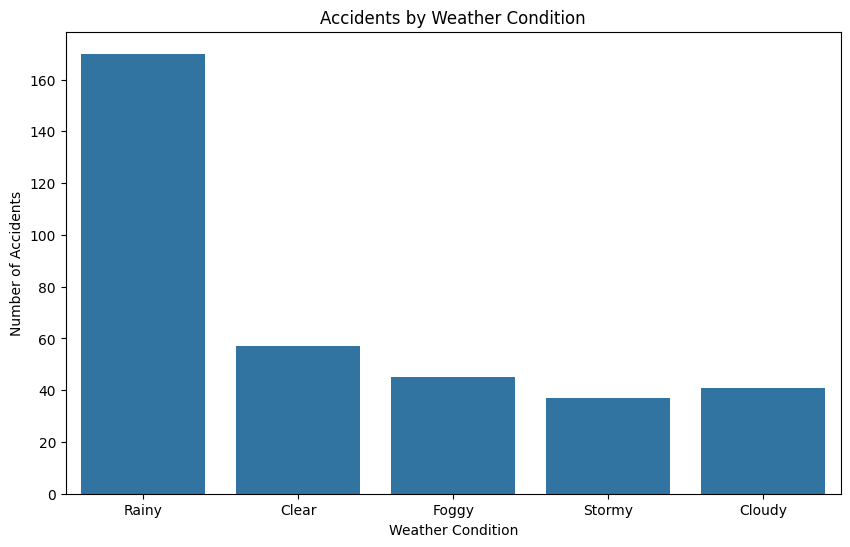

In [21]:
# ============================================================
# STEP 6: WEATHER CONDITION ANALYSIS
# ============================================================

print("\nWeather Condition Counts:\n")
print(df['Weather_Condition'].value_counts())

plt.figure(figsize=(10,6))

sns.countplot(x='Weather_Condition', data=df)

plt.title('Accidents by Weather Condition')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')

plt.show()


Time of Day Counts:

Time_of_Day
Night        132
Afternoon     79
Morning       78
Evening       61
Name: count, dtype: int64


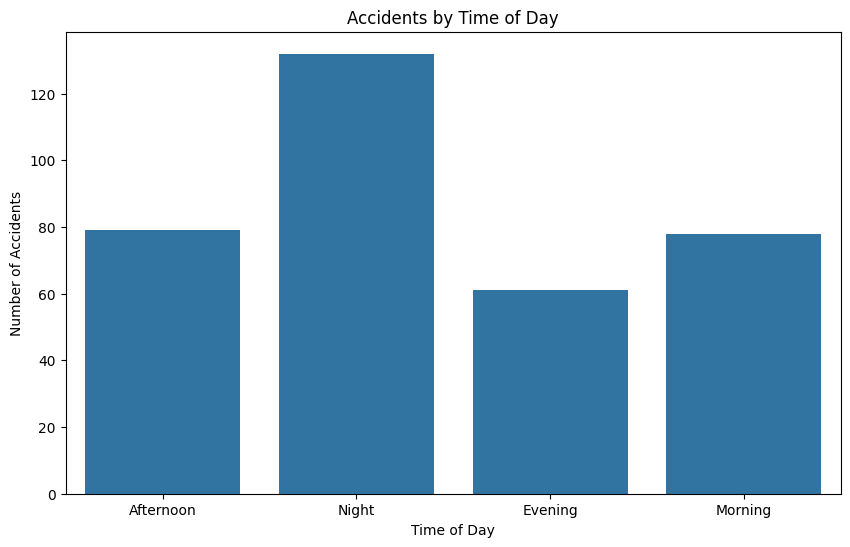

In [22]:
# ============================================================
# STEP 7: TIME OF DAY ANALYSIS
# ============================================================

print("\nTime of Day Counts:\n")
print(df['Time_of_Day'].value_counts())

plt.figure(figsize=(10,6))

sns.countplot(x='Time_of_Day', data=df)

plt.title('Accidents by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Number of Accidents')

plt.show()


Severity Counts:

Severity
Minor    198
Major    113
Fatal     39
Name: count, dtype: int64


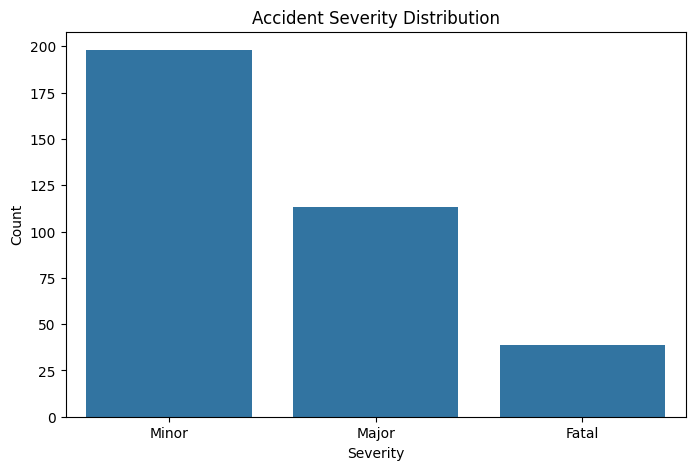

In [23]:
# ============================================================
# STEP 8: ACCIDENT SEVERITY ANALYSIS
# ============================================================

print("\nSeverity Counts:\n")
print(df['Severity'].value_counts())

plt.figure(figsize=(8,5))

sns.countplot(x='Severity', data=df)

plt.title('Accident Severity Distribution')
plt.xlabel('Severity')
plt.ylabel('Count')

plt.show()


Vehicle Type Counts:

Vehicle_Type
Bus              76
Auto Rickshaw    70
Truck            69
Car              69
Bike             66
Name: count, dtype: int64


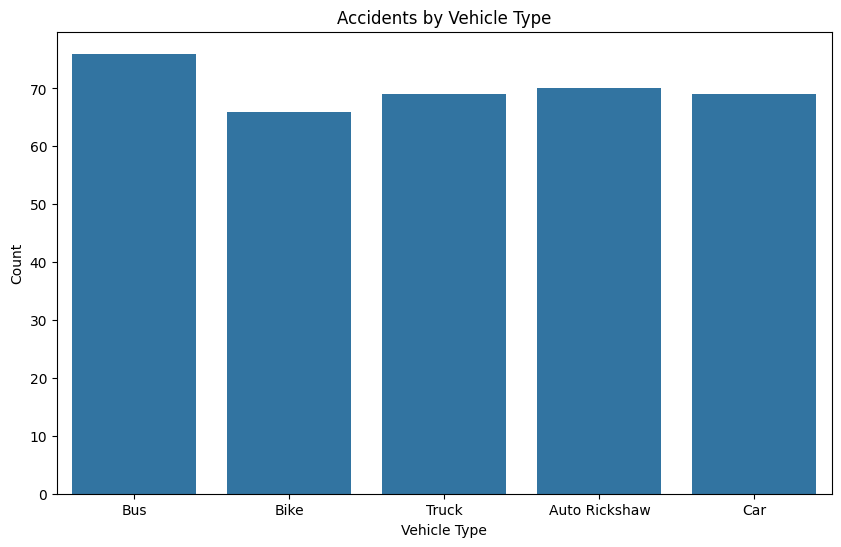

In [24]:
# ============================================================
# STEP 9: VEHICLE TYPE ANALYSIS
# ============================================================

print("\nVehicle Type Counts:\n")
print(df['Vehicle_Type'].value_counts())

plt.figure(figsize=(10,6))

sns.countplot(x='Vehicle_Type', data=df)

plt.title('Accidents by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('Count')

plt.show()


Hotspot Counts:

Location
Downtown Junction    82
Airport Road         75
Industrial Area      69
Highway Exit 5       67
Market Road          57
Name: count, dtype: int64


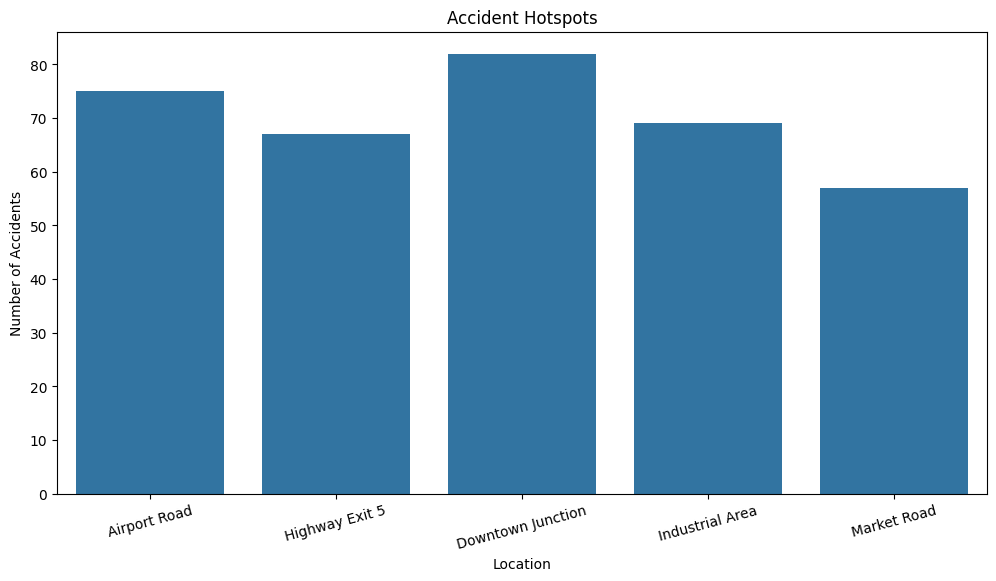

In [25]:
# ============================================================
# STEP 10: ACCIDENT HOTSPOT ANALYSIS
# ============================================================

print("\nHotspot Counts:\n")
print(df['Location'].value_counts())

plt.figure(figsize=(12,6))

sns.countplot(x='Location', data=df)

plt.title('Accident Hotspots')
plt.xlabel('Location')
plt.ylabel('Number of Accidents')

plt.xticks(rotation=15)

plt.show()

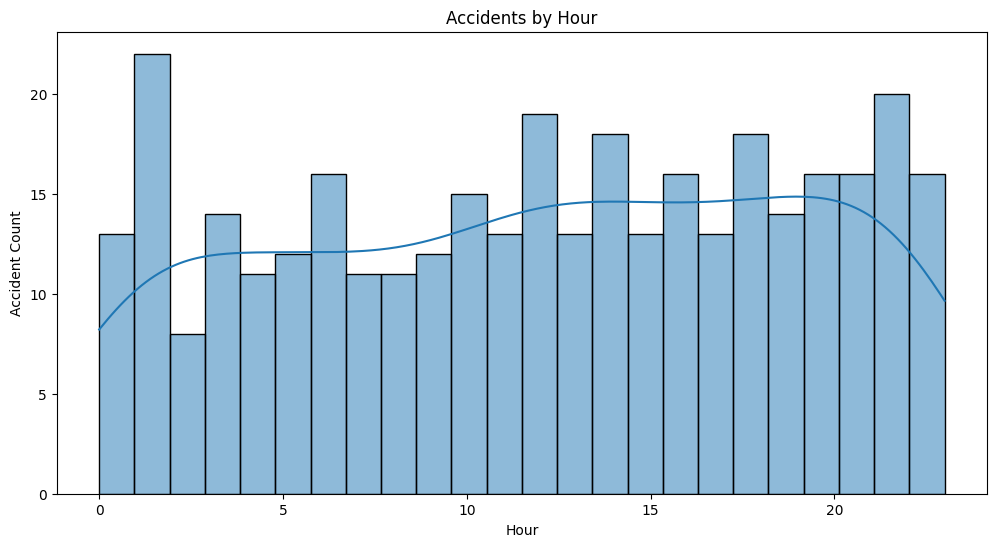

In [26]:
# ============================================================
# STEP 11: ACCIDENTS BY HOUR
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(df['Hour'], bins=24, kde=True)

plt.title('Accidents by Hour')
plt.xlabel('Hour')
plt.ylabel('Accident Count')

plt.show()

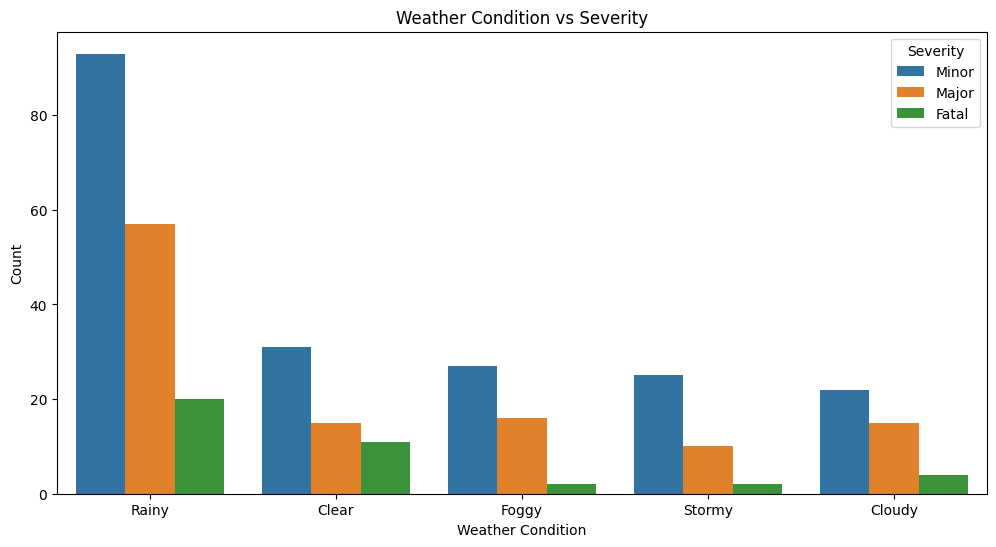

In [27]:
# ============================================================
# STEP 12: WEATHER VS SEVERITY ANALYSIS
# ============================================================

plt.figure(figsize=(12,6))

sns.countplot(x='Weather_Condition',
              hue='Severity',
              data=df)

plt.title('Weather Condition vs Severity')
plt.xlabel('Weather Condition')
plt.ylabel('Count')

plt.show()

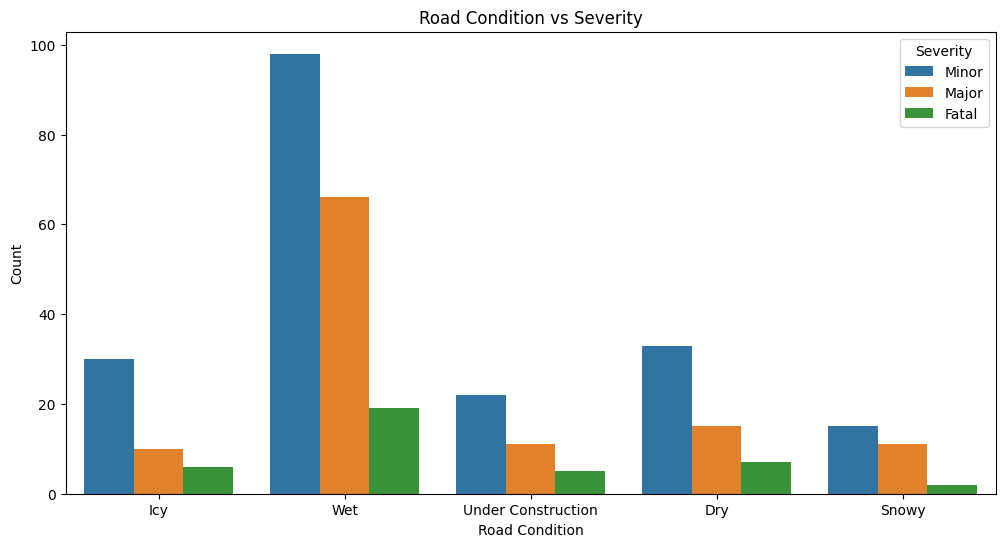

In [28]:
# ============================================================
# STEP 13: ROAD CONDITION VS SEVERITY
# ============================================================

plt.figure(figsize=(12,6))

sns.countplot(x='Road_Condition',
              hue='Severity',
              data=df)

plt.title('Road Condition vs Severity')
plt.xlabel('Road Condition')
plt.ylabel('Count')

plt.show()

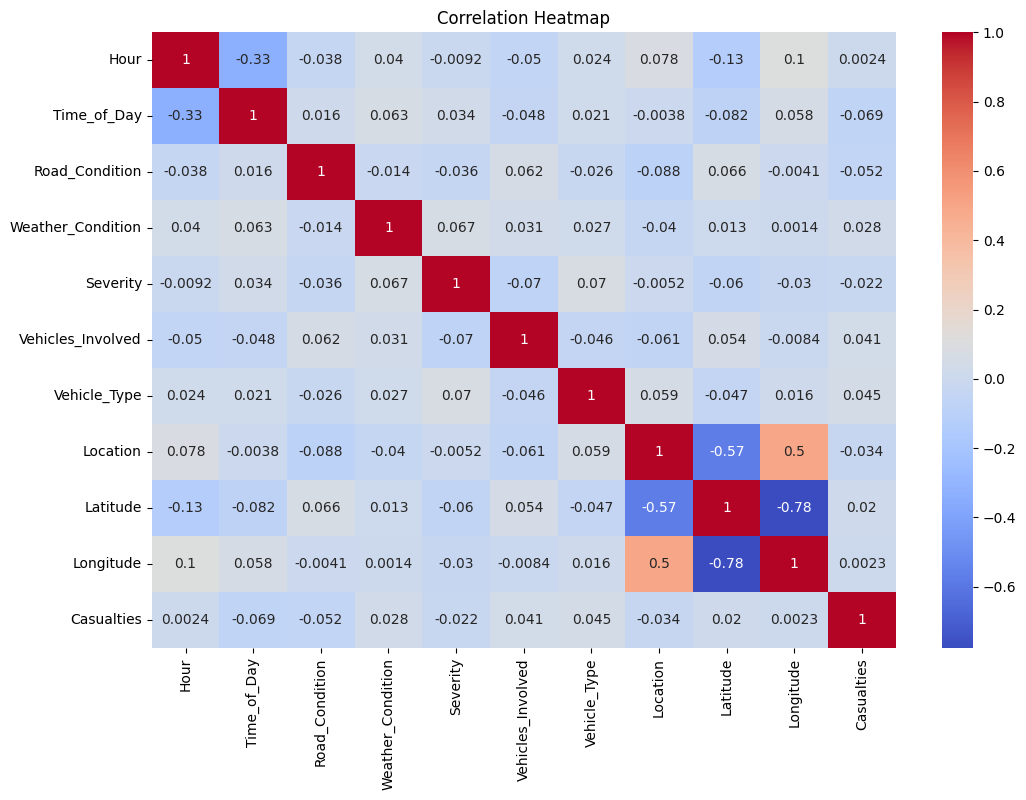

In [29]:
# ============================================================
# STEP 14: CORRELATION HEATMAP
# ============================================================

# Convert categorical columns into numerical values

encoded_df = df.copy()

encoded_df['Road_Condition'] = encoded_df['Road_Condition'].astype('category').cat.codes
encoded_df['Weather_Condition'] = encoded_df['Weather_Condition'].astype('category').cat.codes
encoded_df['Severity'] = encoded_df['Severity'].astype('category').cat.codes
encoded_df['Time_of_Day'] = encoded_df['Time_of_Day'].astype('category').cat.codes
encoded_df['Vehicle_Type'] = encoded_df['Vehicle_Type'].astype('category').cat.codes
encoded_df['Location'] = encoded_df['Location'].astype('category').cat.codes

# Correlation matrix

corr = encoded_df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

In [30]:
# ============================================================
# STEP 15: CREATE ACCIDENT HOTSPOT MAP
# ============================================================

# Create map center

map_center = [df['Latitude'].mean(),
              df['Longitude'].mean()]

# Create folium map

accident_map = folium.Map(location=map_center,
                          zoom_start=12)

# Create heatmap data

heat_data = [[row['Latitude'],
              row['Longitude']]
             for index, row in df.iterrows()]

# Add heatmap

HeatMap(heat_data).add_to(accident_map)

# Save map

accident_map.save("accident_hotspot_map.html")

print("\nHotspot map created successfully!")


Hotspot map created successfully!


In [31]:
# ============================================================
# STEP 16: SAVE CLEANED DATASET
# ============================================================

df.to_csv("cleaned_traffic_accident_data.csv",
          index=False)

print("\nCleaned dataset saved successfully!")



Cleaned dataset saved successfully!
